# Test Gabor filter generation
## Raw, pixel-based Gabor filter generation 

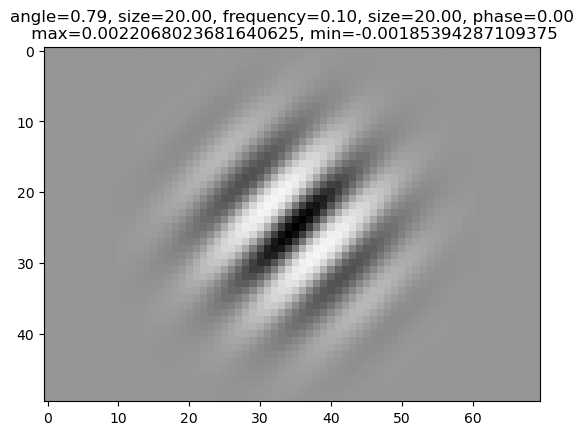

In [5]:
from wavelet_utils import makeGaborFilter2
import numpy as np
angle_deg=45
angle=np.deg2rad(angle_deg)
phase=0

screen_x=70 #pixels
screen_y=50 
i=screen_x//2 #pixels
j=screen_y//2

size=20 #pixels
frequency=0.1 #cycles per pixel


screen=makeGaborFilter2(i, j, angle, size, frequency, phase, screen_x=screen_x, screen_y=screen_y, plot=True)

## Display usable range

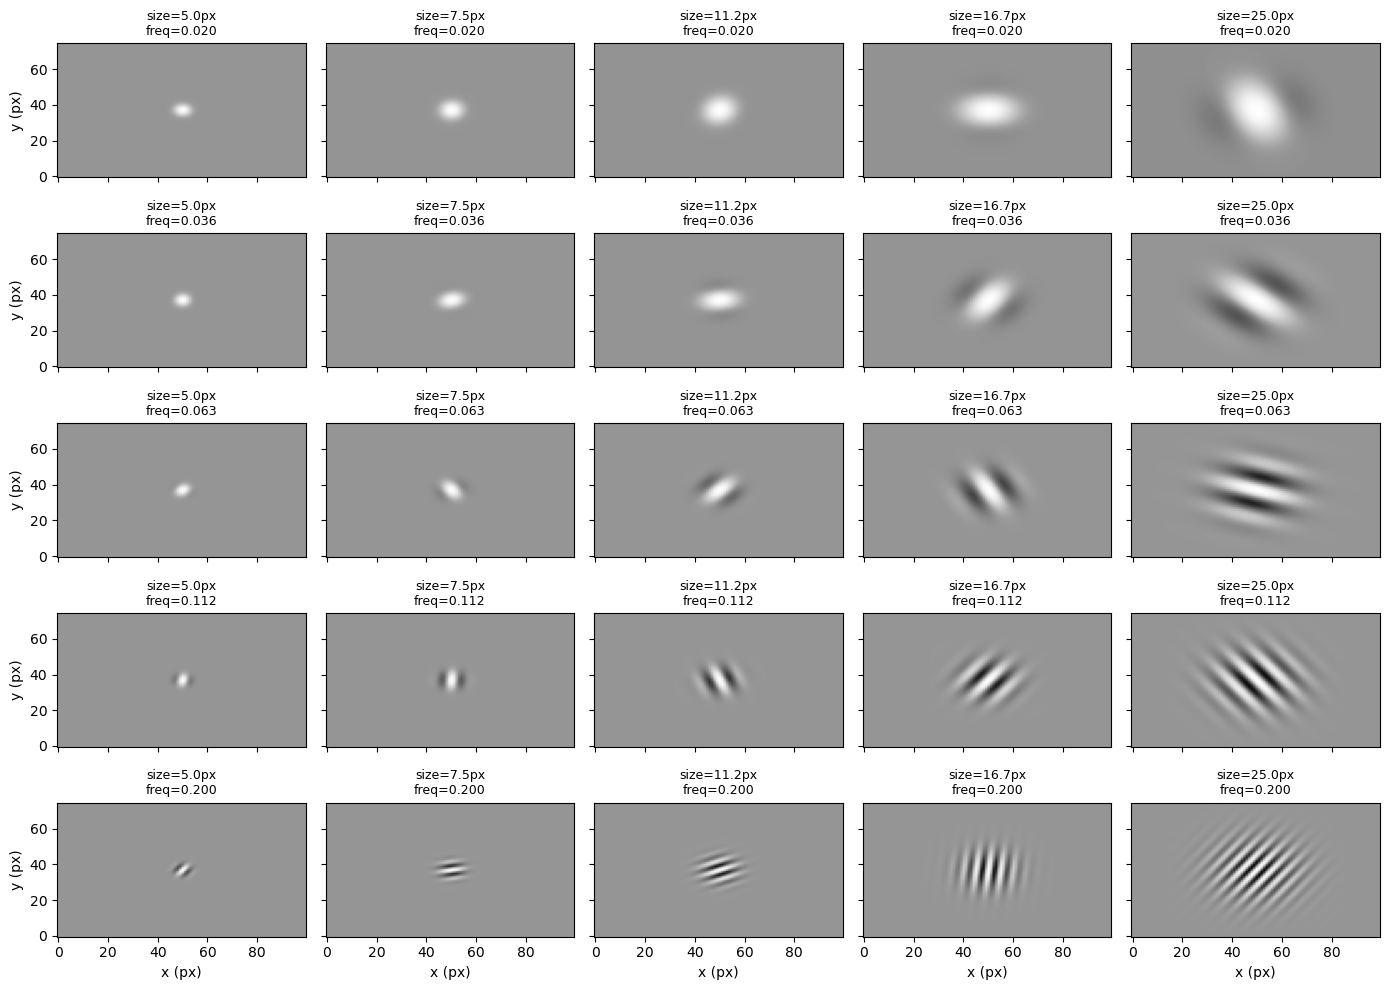

In [6]:
import numpy as np
import matplotlib.pyplot as plt

screen_x = 100
screen_y = 75

# center in pixels
i = screen_x // 2
j = screen_y // 2

sizes = np.logspace(np.log10(5), np.log10(25), 5)
freqs = np.logspace(np.log10(0.02), np.log10(0.2), 5)

phase = 3.14

fig, axes = plt.subplots(len(freqs), len(sizes), figsize=(14, 10), sharex=True, sharey=True)

for row, frequency in enumerate(freqs):
    for col, size in enumerate(sizes):
        angle = np.random.uniform(0, np.pi)

        


        filt = makeGaborFilter2(
            i=i,
            j=j,
            angle=angle,
            size=size,
            phase=phase,
            frequency=frequency,
            screen_x=screen_x,
            screen_y=screen_y,
            plot=False
        )

        ax = axes[row, col]
        v = np.max(np.abs(filt))

        ax.imshow(
            filt.T,
            cmap="Greys",
            vmin=-v,
            vmax=v,
            origin="lower",
            aspect="auto"
        )

        ax.set_title(
            f"size={size:.1f}px\nfreq={frequency:.3f}",
            fontsize=9
        )

        if row == len(freqs) - 1:
            ax.set_xlabel("x (px)")
        if col == 0:
            ax.set_ylabel("y (px)")

plt.tight_layout()
plt.show()

## Visual degree-based Gabor filter generation

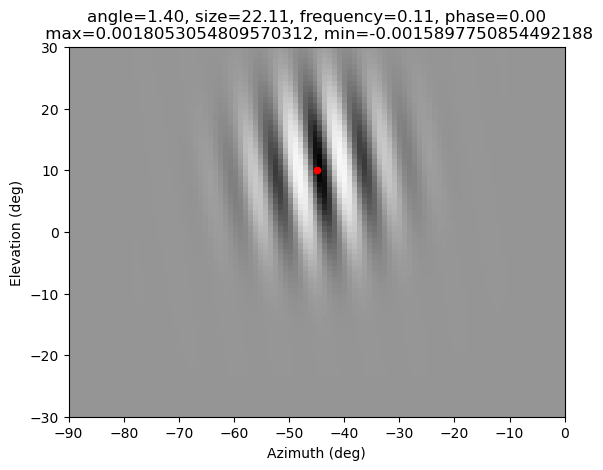

In [7]:
from wavelet_utils import makeGaborFilter_visual
import numpy as np

visual_coverage = [-90, 0, -30, 30]
angle_deg=80
angle=np.deg2rad(angle_deg)
phase=0

screen_x=100
screen_y=None

i=-45
j=10

size=20 #degrees
freq2=.1

screen=makeGaborFilter_visual(i, j,  angle, size, freq2, phase, visual_coverage, screen_x=screen_x, screen_y=screen_y, plot=True)

## Display usable range

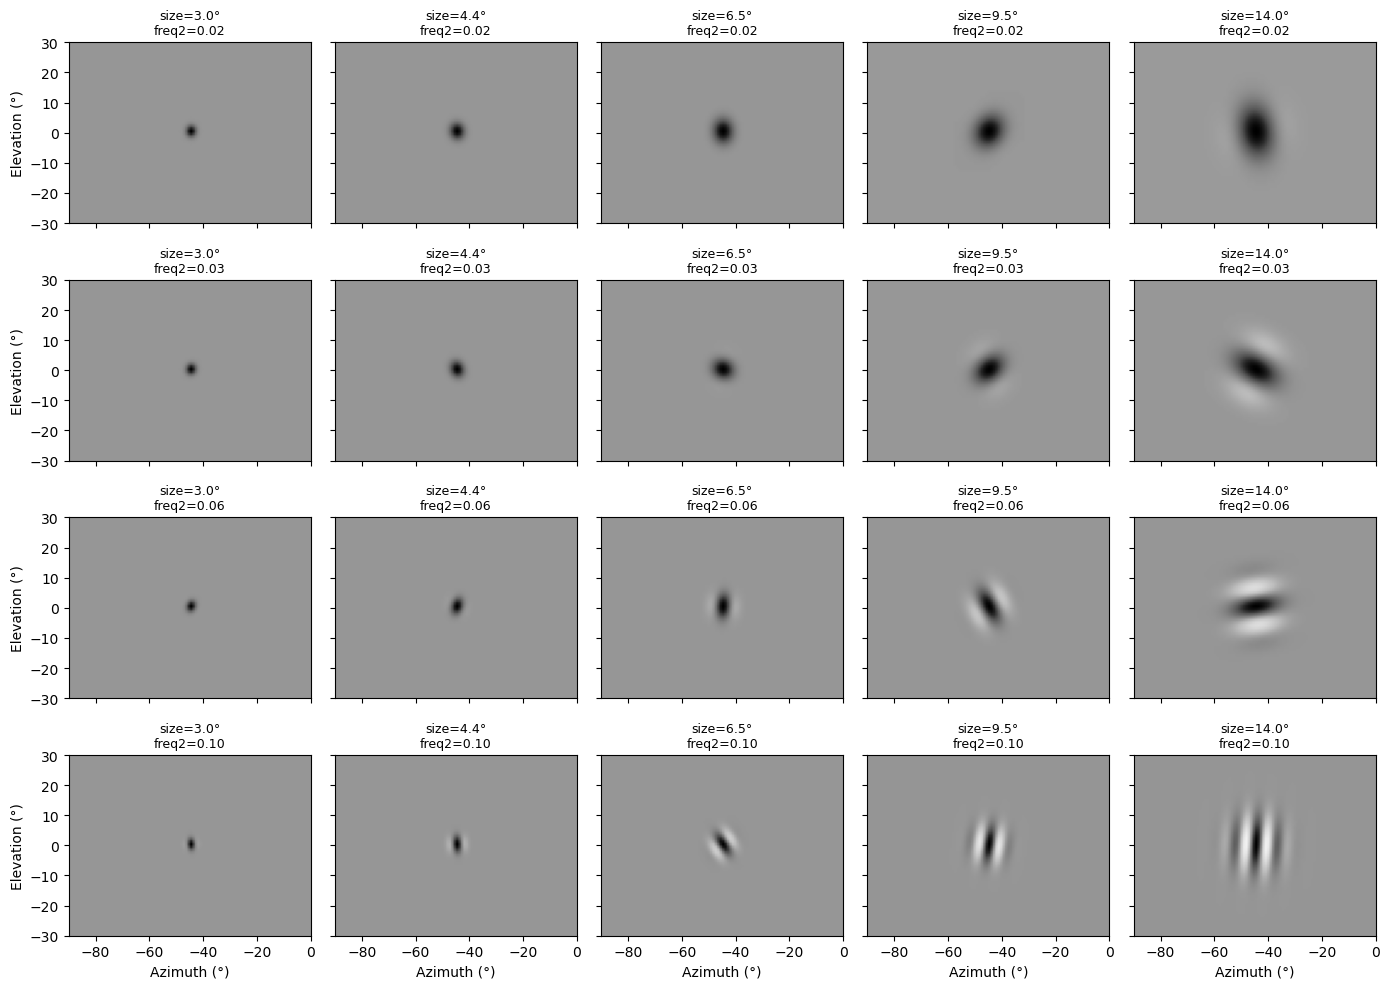

In [8]:
import numpy as np
import matplotlib.pyplot as plt

visual_coverage = [-90, 0, -30, 30]
screen_x = 100
screen_y = None

az_left, az_right, el_bottom, el_top = visual_coverage

# center in visual degrees
i_deg = (az_left + az_right) / 2
j_deg = (el_bottom + el_top) / 2

sizes = np.logspace(np.log10(3), np.log10(14), 5)
freq2s = np.logspace(np.log10(.02), np.log10(.1), 4)

phase = np.pi / 2
phase = 0

fig, axes = plt.subplots(len(freq2s), len(sizes), figsize=(14, 10), sharex=True, sharey=True)

for row, freq2 in enumerate(freq2s):
    for col, size_deg in enumerate(sizes):
        angle = np.random.uniform(0, np.pi)

        filt = makeGaborFilter_visual(
            i_deg=i_deg,
            j_deg=j_deg,
            angle=angle,
            size_deg=size_deg,
            freq_deg=freq2,
            phase=phase,
            visual_coverage=visual_coverage,
            screen_x=screen_x,
            screen_y=screen_y,
            plot=False
        )

        ax = axes[row, col]

        v = np.max(np.abs(filt))

        ax.imshow(
            filt.T,  
            cmap="Greys",
            vmin=-v,
            vmax=v,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto"
        )

        ax.set_title(
            f"size={size_deg:.1f}°\nfreq2={freq2:.2f}",
            fontsize=9
        )

        if row == len(freq2s) - 1:
            ax.set_xlabel("Azimuth (°)")
        if col == 0:
            ax.set_ylabel("Elevation (°)")

plt.tight_layout()
plt.show()